# Laboratorio 2 - Milton Beltrán 
---

## 0. Preparación del corpus


Pipeline heredado del Lab #1: **tokenización → minúsculas → sin puntuación → sin stopwords →
stemming**.



In [1]:
# =========================================================
# Importación de librerías
# =========================================================

# --- Librerías estándar de Python ---
from collections import Counter          

# --- Manejo de datos y gráficos ---
import pandas as pd                      
import numpy as np                       
import matplotlib.pyplot as plt          

# --- NLP con NLTK (mismo pipeline del Laboratorio #1) ---
import nltk
from nltk.tokenize import word_tokenize  
from nltk.corpus import stopwords        
from nltk.stem import SnowballStemmer    

# --- Representaciones de texto con scikit-learn (nuevo en el Laboratorio #2) ---
from sklearn.feature_extraction.text import CountVectorizer  
from sklearn.feature_extraction.text import TfidfVectorizer  
from sklearn.metrics.pairwise import cosine_similarity       


In [ ]:
# --- Carga del corpus y limpieza de filas inservibles ---
# Columnas: url (metadato, no se usa), news (texto de la noticia), Type (categoría).
df = pd.read_csv("df_total.csv")

# En el Lab #1 se detectaron 75 filas exactamente duplicadas. Se eliminan antes de normalizar.
df_prep = df.drop_duplicates().reset_index(drop=True)
print("Documentos originales:", len(df))
print("Documentos tras quitar duplicados:", len(df_prep))

# Hallazgo nuevo de este laboratorio: dos noticias tienen como texto un único espacio.
# No son nulos, así que pasaron el chequeo de nulos del Lab #1, pero al normalizar quedan
# como filas de puros ceros: en la Sección 5 darían similitud coseno 0 contra todo y
# hundirían el promedio de sus categorías. Se eliminan.
vacios = df_prep["news"].str.strip() == ""
print("Documentos con texto vacío:", int(vacios.sum()), "->", df_prep.loc[vacios, "Type"].tolist())

df_prep = df_prep[~vacios].reset_index(drop=True)
print("Documentos de trabajo:", len(df_prep))
print("Categorías:", df_prep["Type"].nunique())
df_prep.head()


In [3]:
# =========================================================
# Pipeline de normalización (heredado del Laboratorio #1)
# tokenización -> minúsculas -> sin puntuación -> sin stopwords -> stemming
# =========================================================

stop_es = set(stopwords.words("spanish"))
stemmer = SnowballStemmer("spanish")

# i. Tokenización: partir cada noticia en tokens. language="spanish" hace que el tokenizador use las reglas de abreviaturas del español.
df_prep["tokens"] = df_prep["news"].apply(
    lambda t: word_tokenize(t, language="spanish")
)

# ii. Minúsculas: unificar variantes de la misma palabra ("El", "el", "EL" -> "el").
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok.lower() for tok in lista]
)

# iii. Quitar puntuación: isalpha() conserva solo tokens alfabéticos. Elimina signos (incluidos ¿ ¡ « ») y mantiene tildes y ñ. 
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok.isalpha()]
)

# iv. Quitar stopwords: palabras muy frecuentes y poco informativas (de, la, que...).
df_prep["tokens"] = df_prep["tokens"].apply(
    lambda lista: [tok for tok in lista if tok not in stop_es]
)

# v. Stemming ("lematización"): NLTK no tiene lematizador para español (WordNet es solo inglés), así que SnowballStemmer recorta cada palabra a una raíz aproximada.
#    Se conservan las dos versiones del corpus:
#      tokens_norm -> sin stemming, palabras legibles (para interpretar resultados)
#      tokens_stem -> con stemming, raíces (base de TODAS las representaciones del lab)
df_prep["tokens_norm"] = df_prep["tokens"]

df_prep["tokens_stem"] = df_prep["tokens_norm"].apply(
    lambda lista: [stemmer.stem(tok) for tok in lista]
)


def contar(col_de_listas):
    """Aplana una columna de listas de tokens y devuelve (tokens, tipos).

    - tokens: total de ocurrencias (con repeticiones).
    - tipos:  palabras distintas (el vocabulario).
    """
    todos = [tok for lista in col_de_listas for tok in lista]
    return len(todos), len(set(todos))


tok, tip = contar(df_prep["tokens_stem"])
print(f"Corpus normalizado: documentos={len(df_prep):,}  tokens={tok:,}  tipos={tip:,}")
print("Ejemplo doc 0, legible:", df_prep["tokens_norm"].iloc[0][:12])
print("Ejemplo doc 0, raíces:", df_prep["tokens_stem"].iloc[0][:12])


Corpus normalizado: documentos=1,142  tokens=299,799  tipos=13,103
Ejemplo doc 0, legible: ['foro', 'banca', 'articulador', 'empresarial', 'desarrollo', 'sostenible', 'director', 'sostenibilidad', 'clientes', 'globales', 'bbva', 'colombia']
Ejemplo doc 0, raíces: ['for', 'banc', 'articul', 'empresarial', 'desarroll', 'sosten', 'director', 'sostenibil', 'client', 'global', 'bbva', 'colombi']


In [4]:
# =========================================================
# Del corpus tokenizado al formato que espera scikit-learn
# =========================================================
# CountVectorizer y TfidfVectorizer NO reciben listas de tokens: esperan un iterable de STRINGS (un documento por elemento) y ellos mismos lo vuelven a partir con su propio analizador interno.
# Puede parecer contradictorio volver a pegar lo que acabamos de separar, pero es lo que mantiene el pipeline del Lab #1 como única fuente de verdad: al unir los tokens con un espacio simple, el re-tokenizado de sklearn es trivial y no puede deshacer ninguna de las decisiones ya tomadas (minúsculas, puntuación, stopwords, stemming).
df_prep["texto_norm"] = df_prep["tokens_stem"].apply(lambda lista: " ".join(lista))

print("Tipo de dato de cada fila:", type(df_prep["texto_norm"].iloc[0]).__name__)
print("Documentos listos para vectorizar:", len(df_prep))
print("Columnas del DataFrame:", list(df_prep.columns))
print()
print("Documento 0, primeros 300 caracteres:")
print(df_prep["texto_norm"].iloc[0][:300])


Tipo de dato de cada fila: str
Documentos listos para vectorizar: 1142
Columnas del DataFrame: ['url', 'news', 'Type', 'tokens', 'tokens_norm', 'tokens_stem', 'texto_norm']

Documento 0, primeros 300 caracteres:
for banc articul empresarial desarroll sosten director sostenibil client global bbva colombi andres garc asegur import entend sostenibil pod asoci mayor cost cre ten concept negoci sosten pued ten mayor impact garc ret import cambi prioridad compit necesari cas deb trat manten priorid cuant ambicion


## 1. Bolsa de palabras (Bag of Words)

Primera representación del corpus: una **matriz documento-término** construida con
`CountVectorizer`. Cada fila es un documento, cada columna una palabra del vocabulario y
cada celda el número de veces que esa palabra aparece en ese documento.


In [5]:
# --- 1.1 Construcción de la matriz BoW ---
# Se mantiene el token_pattern por defecto, r"(?u)\b\w\w+\b", que exige al menos dos caracteres: los tokens de una sola letra que quedan tras la normalización son ruido (se verifica abajo). 
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df_prep["texto_norm"])

vocabulario = bow_vectorizer.get_feature_names_out()
_, tipos_corpus = contar(df_prep["tokens_stem"])

print("Matriz BoW (documentos x vocabulario):", X_bow.shape)
print(f"  documentos : {X_bow.shape[0]:,}")
print(f"  vocabulario: {X_bow.shape[1]:,}")
print(f"Tipos en el corpus normalizado: {tipos_corpus:,}")
print(f"Descartados por token_pattern: {tipos_corpus - X_bow.shape[1]}")
print("Objeto devuelto:", type(X_bow).__name__, "| dtype:", X_bow.dtype)

# Los tokens descartados: letras sueltas, sin valor semántico.
descartados = sorted(t for t in set(t for l in df_prep["tokens_stem"] for t in l) if len(t) < 2)
print("Tokens descartados:", descartados)


Matriz BoW (documentos x vocabulario): (1142, 13080)
  documentos : 1,142
  vocabulario: 13,080
Tipos en el corpus normalizado: 13,103
Descartados por token_pattern: 23
Objeto devuelto: csr_matrix | dtype: int64
Tokens descartados: ['b', 'c', 'd', 'f', 'g', 'h', 'i', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'z', 'π']


In [6]:
# --- 1.2 Cómo se ve la matriz ---
# Fragmento legible: los 8 términos más frecuentes del corpus en los primeros 5 documentos.
frec_global = np.asarray(X_bow.sum(axis=0)).ravel()
top_idx = frec_global.argsort()[::-1][:8]

fragmento = pd.DataFrame(
    X_bow[:5, top_idx].toarray(),
    columns=vocabulario[top_idx],
    index=[f"doc {i}" for i in range(5)],
)
print("Términos más frecuentes del corpus (raíces):", list(vocabulario[top_idx]))
fragmento


Términos más frecuentes del corpus (raíces): ['bbva', 'econom', 'banc', 'pais', 'inflacion', 'empres', 'nuev', 'año']


,bbva,econom,banc,pais,inflacion,empres,nuev,año
doc 0,1,0,1,0,0,0,0,0
doc 1,0,0,1,0,0,7,2,0
doc 2,0,0,0,0,0,1,3,4
doc 3,0,0,0,1,3,0,1,2
doc 4,1,2,5,4,1,1,1,0


In [7]:
# --- 1.3 Evidencia de lo que se pierde ---
# Dos frases con las mismas palabras en distinto orden y significado opuesto.
demo = ["banco demanda empresa", "empresa demanda banco"]
X_demo = CountVectorizer().fit_transform(demo).toarray()

print(pd.DataFrame(X_demo, columns=["banco", "demanda", "empresa"], index=demo))
print("¿Vectores idénticos?", bool((X_demo[0] == X_demo[1]).all()))


                       banco  demanda  empresa
banco demanda empresa      1        1        1
empresa demanda banco      1        1        1
¿Vectores idénticos? True


### 1.4 Resultados y discusión

**Forma de la matriz:** `(1142, 13080)` — 1,142 documentos × 13,080 palabras de vocabulario.

El vocabulario tiene 23 entradas menos que los 13,103 tipos del corpus normalizado. La causa
no es la normalización sino el parámetro `token_pattern` de `CountVectorizer`, cuyo valor por
defecto `(?u)\b\w\w+\b` exige tokens de al menos dos caracteres. Los 23 descartados son letras
sueltas y el símbolo `π`, residuos sin valor semántico, así que se mantiene el comportamiento
por defecto de forma deliberada.

#### ¿Qué información se pierde?

Cuando tratamos el documento como una "Bolsa de palabras" la pérdida más evidente que podemos encontrar es en el orden, no solo por como las almacena y como lo visualizamos, sino que este puede dictar dos conceptos totalmente diferentes. En la celda 1.3 podemos visualizarlo claramente, "banco demanda empresa" y "empresa demanda banco" son dos expresiones que contienen exactamente las mismas palabras, pero con significados completamente distintos. A pesar de esto, los vectores produdicos son **idénticos**. Dado que este corpus es sobre noticias económicas, este detalle no es menor, las relaciones son direccionales con un propósito y pueden crear data falsa por una mala interpretación. 

Por otro lado, Desaparecen las relaciones de sujeto, verbo y objeto, y con ellas la posibilidad de saber qué modifica a qué. También se pierde la negación: *"la empresa no cumplió la meta"* y *"la empresa cumplió la meta"* quedan casi idénticas, separadas por un único conteo.

Por último, Cada palabra se cuenta aislada, así que una misma forma con dos significados (*banco* financiero y. *banco* de datos) colapsa en una sola columna, y las expresiones de varias palabras se rompen. Esta pérdida en particular es la que motiva la Sección 3 (n-gramas).


#### ¿Qué se gana a cambio?

La principal ventaja es conseguir un espacio vectorial, el benficio no se reduce a "es más simple", sino que cada documento pasa a ser un punto en un espacio de 13,080 dimensiones, todos con el mismo número de coordenadas sin importar si el artículo tenía 80 o 3,000 palabras. Eso convierte preguntas sobre texto en operaciones de álgebra lineal, que es lo que permite medir distancias entre documentos o alimentar un clasificador. Con texto crudo, de longitud variable, ninguna de las dos cosas es posible directamente.


Gracias a esto, conseguimos una longitud fija e independiente del documento. Todo modelo de machine learning clásico exige entradas con el mismo número de características; BoW es la traducción más directa de texto a ese formato.

Por último, ganamos un costo de computación bajo. Construir la BoW es un solo recorrido del corpus, y como la inmensa mayoría de las celdas son cero se almacena de forma dispersa, no densa. 


## 2. Vectores de conteo y dispersión

La matriz BoW es enorme pero está casi vacía. Esta sección cuantifica esa **dispersión**
(*sparsity*), mide cómo cambia al recortar el vocabulario y explica por qué obliga a usar
estructuras de almacenamiento especiales.


In [8]:
# --- 2.1 Porcentaje de celdas en cero ---
# nnz ("number of non-zero") es el número de celdas realmente ocupadas: la matriz solo guarda esas, así que la dispersión sale de compararlas contra el total teórico.
n_docs, n_vocab = X_bow.shape
celdas = n_docs * n_vocab
sparsity = 100 * (1 - X_bow.nnz / celdas)

print(f"Celdas totales (docs x vocabulario): {celdas:,}")
print(f"Celdas distintas de cero (nnz)     : {X_bow.nnz:,}")
print(f"Celdas en cero                     : {celdas - X_bow.nnz:,}")
print(f"Dispersión                         : {sparsity:.2f}%")
print(f"Densidad                           : {100 - sparsity:.2f}%")

# Costo de almacenamiento: denso vs. disperso.
bytes_denso = celdas * X_bow.dtype.itemsize
bytes_csr = X_bow.data.nbytes + X_bow.indices.nbytes + X_bow.indptr.nbytes
print(f"\nMatriz densa (int64): {bytes_denso / 1e6:,.1f} MB")
print(f"Matriz dispersa (CSR): {bytes_csr / 1e6:,.2f} MB")
print(f"Factor de ahorro     : {bytes_denso / bytes_csr:.0f}x")


Celdas totales (docs x vocabulario): 14,937,360
Celdas distintas de cero (nnz)     : 192,895
Celdas en cero                     : 14,744,465
Dispersión                         : 98.71%
Densidad                           : 1.29%

Matriz densa (int64): 119.5 MB
Matriz dispersa (CSR): 2.32 MB
Factor de ahorro     : 52x


In [9]:
# --- 2.2 Dispersión al limitar el vocabulario ---
# max_features conserva solo las N palabras más frecuentes del corpus. Además de la dispersión, se mide la COBERTURA: qué porcentaje de las ocurrencias totales sobrevive al recorte, que es lo que dice cuánta información se pierde a cambio.
tamanos = [100, 500, 1000, 5000, None]
filas = []

for mf in tamanos:
    Xi = CountVectorizer(max_features=mf).fit_transform(df_prep["texto_norm"])
    celdas_i = Xi.shape[0] * Xi.shape[1]
    filas.append({
        "max_features": "completo" if mf is None else f"{mf:,}",
        "vocabulario": Xi.shape[1],
        "no_ceros": Xi.nnz,
        "dispersion_%": 100 * (1 - Xi.nnz / celdas_i),
        "cobertura_%": 100 * Xi.sum() / X_bow.sum(),
    })

tabla_disp = pd.DataFrame(filas)
print(tabla_disp.to_string(index=False, float_format=lambda v: f"{v:.2f}"))


max_features  vocabulario  no_ceros  dispersion_%  cobertura_%
         100          100     35825         68.63        25.24
         500          500     99805         82.52        58.26
       1,000         1000    133312         88.33        74.01
       5,000         5000    181752         96.82        95.85
    completo        13080    192895         98.71       100.00


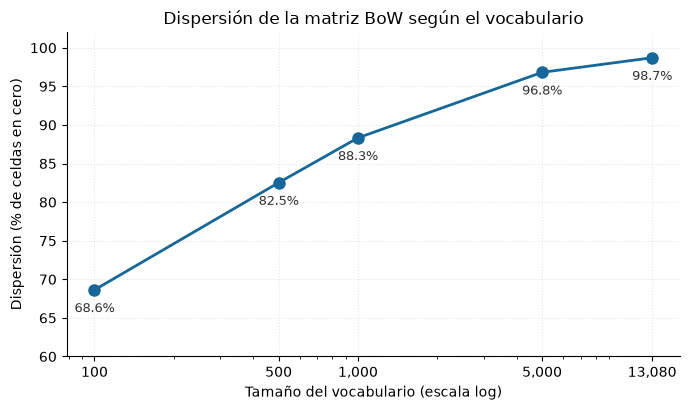

In [10]:
# --- 2.3 Gráfica: dispersión vs. tamaño del vocabulario ---
# Eje x logarítmico porque el vocabulario va de 100 a 13,080: en escala lineal los cuatro primeros puntos quedarían amontonados contra el eje.
plt.figure(figsize=(7, 4.2))
plt.plot(
    tabla_disp["vocabulario"], tabla_disp["dispersion_%"],
    marker="o", markersize=8, linewidth=2, color="#16679a",
)

# Etiqueta directa en cada punto: son solo 5 y sus valores son el resultado a reportar.
for x, y in zip(tabla_disp["vocabulario"], tabla_disp["dispersion_%"]):
    plt.annotate(f"{y:.1f}%", (x, y), textcoords="offset points",
                 xytext=(0, -16), ha="center", fontsize=9, color="#333333")

plt.xscale("log")
plt.xticks(tabla_disp["vocabulario"], [f"{v:,}" for v in tabla_disp["vocabulario"]])
plt.ylim(60, 102)
plt.xlabel("Tamaño del vocabulario (escala log)")
plt.ylabel("Dispersión (% de celdas en cero)")
plt.title("Dispersión de la matriz BoW según el vocabulario")
plt.grid(alpha=0.3, linestyle=":")
plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("reporte/img/dispersion.png", dpi=120)
plt.show()


In [11]:
# --- 2.4 Por qué la matriz está tan vacía ---
# Dos vistas del mismo fenómeno: cuántas columnas usa cada documento, y en cuántos documentos aparece cada término.
row_nnz = np.diff(X_bow.indptr)           # palabras distintas por documento
col_nnz = np.diff(X_bow.tocsc().indptr)   # documentos en que aparece cada término

print("Palabras distintas por documento:")
print(f"  media={row_nnz.mean():.0f}  mediana={np.median(row_nnz):.0f}  mín={row_nnz.min()}  máx={row_nnz.max()}")
print(f"  el documento promedio usa el {100 * row_nnz.mean() / n_vocab:.2f}% del vocabulario")

print("\nDistribución de los términos en el corpus:")
print(f"  aparecen en 1 solo documento : {(col_nnz == 1).sum():,} ({100 * (col_nnz == 1).mean():.1f}% del vocabulario)")
print(f"  aparecen en <= 3 documentos  : {(col_nnz <= 3).sum():,} ({100 * (col_nnz <= 3).mean():.1f}% del vocabulario)")
print(f"  aparecen en > 100 documentos : {(col_nnz > 100).sum():,} ({100 * (col_nnz > 100).mean():.1f}% del vocabulario)")


Palabras distintas por documento:
  media=169  mediana=154  mín=0  máx=666
  el documento promedio usa el 1.29% del vocabulario

Distribución de los términos en el corpus:
  aparecen en 1 solo documento : 6,000 (45.9% del vocabulario)
  aparecen en <= 3 documentos  : 8,539 (65.3% del vocabulario)
  aparecen en > 100 documentos : 476 (3.6% del vocabulario)


In [12]:
# --- 2.5 Qué hay dentro de una matriz CSR ---
# Ejemplo mínimo de 3 documentos para ver los tres arreglos que componen el formato.
mini_cv = CountVectorizer()
mini = mini_cv.fit_transform(["banco banco credito", "credito empresa", "banco"])

print("Vocabulario:", list(mini_cv.get_feature_names_out()))
print("\nComo matriz densa (9 celdas, 4 de ellas en cero):")
print(mini.toarray())

print("\nComo la guarda CSR (solo 5 valores):")
print("  data   :", mini.data, "   <- los valores distintos de cero, fila por fila")
print("  indices:", mini.indices, "   <- la columna a la que pertenece cada valor")
print("  indptr :", mini.indptr, " <- dónde empieza y termina cada fila")
print("\nLectura de indptr: la fila 0 ocupa data[0:2], la fila 1 data[2:4], la fila 2 data[4:5].")

# Los mismos tres arreglos en la matriz real del corpus.
print(f"\nEn la matriz BoW completa ({X_bow.shape[0]:,} x {X_bow.shape[1]:,}):")
print(f"  data   : {X_bow.data.size:,} valores   ({X_bow.data.nbytes / 1e6:.2f} MB)")
print(f"  indices: {X_bow.indices.size:,} valores   ({X_bow.indices.nbytes / 1e6:.2f} MB)")
print(f"  indptr : {X_bow.indptr.size:,} valores      ({X_bow.indptr.nbytes / 1e6:.4f} MB)")


Vocabulario: ['banco', 'credito', 'empresa']

Como matriz densa (9 celdas, 4 de ellas en cero):
[[2 1 0]
 [0 1 1]
 [1 0 0]]

Como la guarda CSR (solo 5 valores):
  data   : [2 1 1 1 1]    <- los valores distintos de cero, fila por fila
  indices: [0 1 1 2 0]    <- la columna a la que pertenece cada valor
  indptr : [0 2 4 5]  <- dónde empieza y termina cada fila

Lectura de indptr: la fila 0 ocupa data[0:2], la fila 1 data[2:4], la fila 2 data[4:5].

En la matriz BoW completa (1,142 x 13,080):
  data   : 192,895 valores   (1.54 MB)
  indices: 192,895 valores   (0.77 MB)
  indptr : 1,143 valores      (0.0046 MB)


### 2.6 Resultados y discusión

**La matriz BoW completa es 98.71% ceros:** de 14,911,200 celdas, solo 192,895 están ocupadas.

| `max_features` | Vocabulario | No-ceros | Dispersión | Cobertura de tokens |
|---|---|---|---|---|
| 100 | 100 | 35,825 | 68.57% | 25.2% |
| 500 | 500 | 99,805 | 82.49% | 58.3% |
| 1,000 | 1,000 | 133,312 | 88.31% | 74.0% |
| 5,000 | 5,000 | 181,752 | 96.81% | 95.9% |
| completo | 13,080 | 192,895 | 98.71% | 100.0% |

#### ¿Por qué crece la dispersión al aumentar el vocabulario?


Porque el numerador y el denominador de la fracción crecen a ritmos distintos. El 45.9% del vocabulario (6,000 términos) aparece en un solo documento. Casi la mitad delas columnas tiene un único valor distinto de cero y 1,139 ceros. 

Un documento usa en promedio 169 palabras distintas, apenas el **1.29%** del vocabulario disponible. Ningún documento se acerca a llenar su fila: el máximo observado son 666 palabrasdistintas, todavía un 5% de las columnas.

#### Implicaciones en almacenamiento y cómputo

- **Almacenamiento.** En formato denso la matriz ocuparía 119.3 MB; en CSR ocupa 2.32 MB, un factor de **51x**. Y esto es un corpus pequeño: 1,140 documentos. Con un millón de documentos y el mismo vocabulario, la versión tendría más de 100 GB, mientras que la dispersa crecería solo en proporción al texto realmente presente.
- **Cómputo.** Las operaciones sobre matrices dispersas recorren únicamente los valores almacenados, así que su costo depende de `nnz` y no de `filas × columnas`.

#### Investigación: matrices dispersas y formato CSR

Una _matriz dispersa_ es una matriz donde la mayoría de sus elementos son cero. Se considera dispersa cuando conviene más almacenar solo sus valores no nulos, junto con su posición, en lugar de reservar memora para la cuadrícula completa. 

El formato **CSR** (*Compressed Sparse Row*) es el que devuelve `CountVectorizer` por defecto. Este tipo de formato es utilizado por diversos beneficios al tratar matrices dispersas, por ejemplo: 
- El costo de memoria se reduce, pasando de {`filas x columas`} a un `X * nnz`, de ahí conseguimos el factor 51x mencionado anteriormente. 
- Los algoritmos de álgebra lineal que presentemos solo operan sobre valores almacenados, permitiendonos tener operaciones más rápidas. 
- Sin este tipo de estructuras, representar corpus de tamaño realista con BoW o TF-IDF sería simplemente imposible en memoria.

## 3. N-gramas

Un **n-grama** es una secuencia de *n* palabras consecutivas. La bolsa de palabras de la
Sección 1 es el caso *n = 1* (unigramas): cada palabra es una columna independiente. Al subir a
*n = 2* (bigramas) las columnas pasan a ser pares de palabras contiguas, lo que devuelve parte
del orden que BoW había descartado.

Se controla con el parámetro `ngram_range=(min_n, max_n)` de `CountVectorizer`.


In [13]:
# --- 3.1 Tamaño del vocabulario según ngram_range ---
configs = [
    ("unigramas", (1, 1)),
    ("bigramas", (2, 2)),
    ("trigramas", (3, 3)),
    ("uni + bi", (1, 2)),
    ("uni + bi + tri", (1, 3)),
]

filas_ng = []
for nombre, rango in configs:
    Xi = CountVectorizer(ngram_range=rango).fit_transform(df_prep["texto_norm"])
    celdas_i = Xi.shape[0] * Xi.shape[1]
    filas_ng.append({
        "configuracion": nombre,
        "ngram_range": str(rango),
        "vocabulario": Xi.shape[1],
        "vs_unigramas": f"{Xi.shape[1] / X_bow.shape[1]:.1f}x",
        "no_ceros": Xi.nnz,
        "dispersion_%": round(100 * (1 - Xi.nnz / celdas_i), 3),
        "memoria_csr_MB": round((Xi.data.nbytes + Xi.indices.nbytes) / 1e6, 1),
    })

tabla_ng = pd.DataFrame(filas_ng)
print(tabla_ng.to_string(index=False))

 configuracion ngram_range  vocabulario vs_unigramas  no_ceros  dispersion_%  memoria_csr_MB
     unigramas      (1, 1)        13080         1.0x    192895        98.709             2.3
      bigramas      (2, 2)       198880        15.2x    281807        99.876             3.4
     trigramas      (3, 3)       271910        20.8x    292948        99.906             3.5
      uni + bi      (1, 2)       211960        16.2x    474702        99.804             5.7
uni + bi + tri      (1, 3)       483870        37.0x    767650        99.861             9.2


In [14]:
# --- 3.2 Los 15 bigramas más frecuentes ---
# Se listan dos veces: sobre el corpus con stemming (el que se usa en todo el laboratorio) y sobre el corpus legible, porque las raíces cortadas dificultan juzgar si un bigrama aporta información. 
def top_ngramas(textos, rango, n=15):
    """Devuelve los n n-gramas más frecuentes de una serie de textos."""
    cv = CountVectorizer(ngram_range=rango)
    X = cv.fit_transform(textos)
    nombres = cv.get_feature_names_out()
    frecs = np.asarray(X.sum(axis=0)).ravel()
    orden = frecs.argsort()[::-1][:n]
    return [(nombres[i], int(frecs[i])) for i in orden]

texto_legible = df_prep["tokens_norm"].apply(lambda lista: " ".join(lista))

top_stem = top_ngramas(df_prep["texto_norm"], (2, 2))
top_leg = top_ngramas(texto_legible, (2, 2))

comparacion = pd.DataFrame({
    "bigrama (raíces)": [b for b, _ in top_stem],
    "frec.": [f for _, f in top_stem],
    "bigrama (legible)": [b for b, _ in top_leg],
    "frec. ": [f for _, f in top_leg],
})
print(comparacion.to_string(index=False))

bigrama (raíces)  frec.  bigrama (legible)  frec. 
    banc central    212      bbva research     186
   bbva research    186           cada vez     183
     tas interes    183      banco central     156
         cad vez    183   cambio climático     148
    cambi climat    150     américa latina     146
      amer latin    146     puntos básicos     136
      millon eur    140     millones euros     136
      punt basic    139        bbva méxico     132
      bbva mexic    132 política monetaria     128
  polit monetari    129         año pasado     124
        pued ser    129 precios consumidor     123
preci consumidor    128      tasas interés     121
         año pas    125     índice precios     112
     indic preci    116       últimos años     106
      ultim años    106        largo plazo     100


In [15]:
# --- 3.3 El costo de los bigramas ---
# El vocabulario no solo crece: crece con basura. Se compara qué proporción de cada vocabulario aparece una sola vez en TODO el corpus (frecuencia total = 1).
def pct_hapax(textos, rango):
    """Porcentaje del vocabulario que aparece una sola vez en todo el corpus."""
    X = CountVectorizer(ngram_range=rango).fit_transform(textos)
    frecs = np.asarray(X.sum(axis=0)).ravel()
    return (frecs == 1).sum(), len(frecs), 100 * (frecs == 1).mean()

for nombre, rango in [("unigramas", (1, 1)), ("bigramas", (2, 2)), ("trigramas", (3, 3))]:
    n_hapax, n_total, pct = pct_hapax(df_prep["texto_norm"], rango)
    print(f"{nombre:>10}: {n_hapax:>7,} de {n_total:>7,} aparecen 1 sola vez ({pct:.1f}%)")

 unigramas:   5,189 de  13,080 aparecen 1 sola vez (39.7%)
  bigramas: 159,228 de 198,880 aparecen 1 sola vez (80.1%)
 trigramas: 255,114 de 271,910 aparecen 1 sola vez (93.8%)


### 3.4 Resultados y análisis

**Tamaño del vocabulario por configuración:**

| Configuración | `ngram_range` | Vocabulario | vs. unigramas | Dispersión |
|---|---|---|---|---|
| Unigramas | `(1, 1)` | 13,080 | 1.0× | 98.706% |
| Bigramas | `(2, 2)` | 198,880 | 15.2× | 99.876% |
| Trigramas | `(3, 3)` | 271,910 | 20.8× | 99.905% |
| Uni + bi | `(1, 2)` | 211,960 | 16.2× | 99.804% |
| Uni + bi + tri | `(1, 3)` | 483,870 | 37.0× | 99.861% |

**Los 15 bigramas más frecuentes** (con *stemming*): `banc central` (212), `bbva research` (186),
`tas interes` (183), `cad vez` (183), `cambi climat` (150), `amer latin` (146), `millon eur` (140),
`punt basic` (139), `bbva mexic` (132), `polit monetari` (129), `pued ser` (129),
`preci consumidor` (128), `año pas` (125), `indic preci` (116), `ultim años` (106).

#### ¿Aportan información que los unigramas no capturan?

Once de los quince sí; cuatro son ruido.

- **Sí aportan.** Conceptos técnicos de banca central (`banc central`, `polit monetari`,
  `tas interes`, `punt basic`), fragmentos del índice de precios (`preci consumidor`,
  `indic preci`) y entidades compuestas (`bbva research`, `bbva mexic`, `amer latin`,
  `millon eur`). Como palabras sueltas no significan nada o significan otra cosa.
- **El mejor caso es `cambi climat`.** `cambi` es de las palabras más ambiguas del corpus —cambio
  de divisas, de directiva, climático— y solo el bigrama aísla el tema de sostenibilidad.
- **Son ruido** `cad vez`, `pued ser`, `año pas` y `ultim años`: muletillas periodísticas que
  aparecen en todas las categorías por igual. Sobreviven porque el filtro de stopwords del Lab #1
  opera palabra por palabra, no sobre pares.

**Matiz metodológico:** los n-gramas se construyen sobre el texto **ya sin stopwords**, así que
unen palabras que en el original no eran contiguas (`tas interes` viene de "tasa **de** interés").
Aquí el efecto compacta conceptos, pero deja de ser cierto que un bigrama represente adyacencia
real en el texto.

#### ¿Qué ventaja ofrecen y qué cuestan?

**La ventaja** es que recuperan parte del contexto local que BoW había tirado: conceptos de varias
palabras, nombres propios compuestos y negaciones del tipo *"no cumplió"*. Es un punto intermedio
entre la bolsa de palabras y un modelo que entienda la secuencia.

**El costo:**

| | Vocabulario | Aparece 1 sola vez |
|---|---|---|
| Unigramas | 13,080 | 5,189 (**39.7%**) |
| Bigramas | 198,880 | 159,228 (**80.1%**) |
| Trigramas | 271,910 | 255,114 (**93.8%**) |

El costo es desproporcionado. Pasar de unigramas a bigramas multiplica el vocabulario por 15.2 y la configuración completa (1,3) por 37. Es tamaño inútil. El 80.1% de los bigramas y el 93.8% de los trigramas aparecen una sola vez en todo el corpus, y una columna que se activa en un único documento no nos permite generalizar ni comparar documentos. Eso mismo explica que la dispersión suba a 99.876% con bigramas y a 99.905% con trigramas, porque el vocabulario se multiplica por 15 o por 20 mientras las celdas ocupadas apenas crecen un 46% y un 52% —cada documento sigue teniendo el mismo texto y lo único que crece es el número de columnas vacías.

**Solución práctica:** con `min_df=2` el vocabulario de bigramas cae de 198,880 a **35,803
términos (−82%)**, eliminando exactamente los pares de un solo documento. Por eso en la práctica
se usa `ngram_range=(1,2)` con poda, nunca bigramas crudos.


## 4. TF-IDF

La bolsa de palabras trata todas las palabras por igual: una que aparece en todos los documentos
pesa lo mismo que una que aparece en uno solo. **TF-IDF** corrige eso multiplicando dos factores:

- **TF** (*term frequency*): cuántas veces aparece el término en **ese** documento. Premia la
  repetición local.
- **IDF** (*inverse document frequency*): cuán raro es el término en **todo** el corpus. Penaliza
  lo que está en todas partes.

`TfidfVectorizer` usa la variante suavizada de scikit-learn,
`idf(t) = ln((1 + n) / (1 + df(t))) + 1`, y además normaliza cada fila a norma L2 para que
documentos de distinta longitud sean comparables. Ambas cosas se verifican en la celda 4.1.


In [ ]:
# --- 4.1 Construcción de la representación TF-IDF ---
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df_prep["texto_norm"])
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print("Matriz TF-IDF:", X_tfidf.shape)
print("¿Misma forma que BoW?", X_tfidf.shape == X_bow.shape)
print("dtype:", X_tfidf.dtype, "(BoW era int64: TF-IDF guarda pesos, no conteos)")

# Verificación 1: sklearn normaliza cada fila a norma L2 = 1, lo que neutraliza la longitud del documento. Es la razón de que luego la similitud coseno sea un simple producto punto.
normas = np.sqrt(X_tfidf.multiply(X_tfidf).sum(axis=1)).A.ravel()
print(f"\nNorma L2 de las filas: mín={normas.min():.6f}  máx={normas.max():.6f}")

# Verificación 2: reproducir a mano la fórmula de IDF de scikit-learn.
idf = dict(zip(vocab_tfidf, tfidf_vectorizer.idf_))
df_docs = np.diff(X_bow.tocsc().indptr)          # en cuántos documentos aparece cada término
idf_manual = np.log((1 + X_bow.shape[0]) / (1 + df_docs)) + 1
print("¿idf_ de sklearn == ln((1+n)/(1+df))+1 calculado a mano?",
      bool(np.allclose(tfidf_vectorizer.idf_, idf_manual)))

print(f"\nRango de IDF: {tfidf_vectorizer.idf_.min():.3f} (término más común) "
      f"a {tfidf_vectorizer.idf_.max():.3f} (término único)")
print("IDF de algunos términos frecuentes del corpus:")
for t in ["bbva", "econom", "banc", "empres", "inflacion", "sosten"]:
    print(f"  idf({t:<10}) = {idf[t]:.3f}   (aparece en {df_docs[list(vocab_tfidf).index(t)]:,} documentos)")

In [ ]:
# --- 4.2 Diccionario para leer las raíces ---
# Las tablas siguientes son ilegibles con raíces cortadas ("desperdici", "inteligent"), así que se arma un glosario raíz -> palabra completa más frecuente del corpus.
formas = {}
for legibles, raices in zip(df_prep["tokens_norm"], df_prep["tokens_stem"]):
    for palabra, raiz in zip(legibles, raices):
        formas.setdefault(raiz, Counter())[palabra] += 1

glosario = {raiz: c.most_common(1)[0][0] for raiz, c in formas.items()}
print("Ejemplos del glosario:")
for r in ["desperdici", "inteligent", "reapertur", "sostenibil", "polit"]:
    print(f"  {r:<12} -> {glosario[r]}")

In [ ]:
# --- 4.3 Selección de 3 documentos de categorías distintas ---
# Para que la elección no sea arbitraria se toma, en cada categoría, el documento cuya longitud es la más cercana a la mediana de esa categoría: ni el más corto ni el más largo.
largos = df_prep["tokens_stem"].apply(len)
categorias_muestra = ["Macroeconomia", "Sostenibilidad", "Innovacion"]

docs_muestra = {}
for cat in categorias_muestra:
    sub = largos[df_prep["Type"] == cat]
    docs_muestra[cat] = int((sub - sub.median()).abs().idxmin())

for cat, i in docs_muestra.items():
    print(f"{cat:<15} doc {i:>4}  ({largos[i]} tokens)")
    print(f"      {df_prep['news'].iloc[i][:110]}...")

In [ ]:
# --- 4.4 Top-10 por TF-IDF vs. top-10 por conteo simple ---
def comparar_rankings(i):
    """Tabla lado a lado de los 10 términos con mayor TF-IDF y los 10 más frecuentes."""
    pesos = X_tfidf[i].toarray().ravel()
    conteos = X_bow[i].toarray().ravel()
    top_tfidf = pesos.argsort()[::-1][:10]
    top_conteo = conteos.argsort()[::-1][:10]

    tabla = pd.DataFrame({
        "término (TF-IDF)": [glosario[vocab_tfidf[j]] for j in top_tfidf],
        "peso": [round(pesos[j], 3) for j in top_tfidf],
        "idf": [round(idf[vocab_tfidf[j]], 2) for j in top_tfidf],
        "n": [int(conteos[j]) for j in top_tfidf],
        "|": ["|"] * 10,
        "término (conteo)": [glosario[vocab_tfidf[j]] for j in top_conteo],
        "n ": [int(conteos[j]) for j in top_conteo],
        "idf ": [round(idf[vocab_tfidf[j]], 2) for j in top_conteo],
    })
    comunes = set(vocab_tfidf[top_tfidf]) & set(vocab_tfidf[top_conteo])
    return tabla, comunes


for cat, i in docs_muestra.items():
    tabla, comunes = comparar_rankings(i)
    print(f"\n===== {cat} — documento {i} =====")
    print(tabla.to_string(index=False))
    print(f"Coincidencias entre ambos rankings: {len(comunes)} de 10")

In [ ]:
# --- 4.5 Qué palabras expulsa el IDF ---
# Los términos que están en el top-10 por conteo pero NO en el top-10 por TF-IDF: son los que el IDF castigó por aparecer en demasiados documentos.
print(f"{'documento':<16}{'término':<16}{'n':>4}{'idf':>7}{'docs en que aparece':>22}")
for cat, i in docs_muestra.items():
    pesos = X_tfidf[i].toarray().ravel()
    conteos = X_bow[i].toarray().ravel()
    top_tfidf = set(vocab_tfidf[pesos.argsort()[::-1][:10]])
    expulsados = [j for j in conteos.argsort()[::-1][:10] if vocab_tfidf[j] not in top_tfidf]

    for j in expulsados:
        t = vocab_tfidf[j]
        print(f"{cat:<16}{glosario[t]:<16}{int(conteos[j]):>4}{idf[t]:>7.2f}{df_docs[j]:>22,}")

### 4.6 Resultados y discusión

La matriz TF-IDF tiene **la misma forma que la de BoW**, `(1140, 13080)`: no cambia qué se
representa, sino **cuánto pesa cada término**. Las celdas pasan de enteros a pesos `float64` y
cada fila queda normalizada a norma L2 = 1. El IDF va de **1.621** (término más extendido) a
**7.347** (términos únicos).

| Categoría | Doc | Tokens | Coincidencias con el top-10 por conteo |
|---|---|---|---|
| Macroeconomía | 1010 | 248 | 6 de 10 |
| Sostenibilidad | 81 | 393 | 4 de 10 |
| Innovación | 134 | 288 | 7 de 10 |

#### ¿Qué papel juegan estas palabras y cómo lo refleja su puntaje?

Son **las que identifican de qué trata específicamente ese artículo**.

- **Macroeconomía (1010)** — `reapertura`, `IPC`, `Powell`, `presiones`, `persistente`. El artículo informa del IPC estadounidense de junio y atribuye las presiones inflacionarias a los costos de la reapertura de la economía.
- **Sostenibilidad (81)** — `desperdicio`, `kilómetros`, `greta`, `thunberg`, `envases`. Desperdicio alimentario y huella de carbono de la comida.
- **Innovación (134)** — `artificial`, `factory`, `ai`, `sofia`, `sintéticos`, `startups`. Una startup de datos sintéticos e inteligencia artificial.


#### ¿Coinciden con el top-10 por conteo simple?

Algunos: 6, 4 y 7 de 10, y el grado de coincidencia nos da bastante información: mide que tan especializado es el vocabulario del documento. Innovación coincide en 7/10 porque suspalabras más repetidas (`artificial`, `factory`, `ai`) ya son raras en el corpus y ambos criterios apuntan al mismo lado; Sostenibilidad solo en 4/10 porque se apoya en vocabulario común.

Lo que el conteo corona y el IDF expulsa:

| Documento | Término | Veces | IDF | Documentos |
|---|---|---|---|---|
| Macroeconomía | `economía` | 3 | 1.70 | 565 de 1,140 |
| Macroeconomía | `parte` | 3 | 1.69 | 572 |
| Sostenibilidad | `cada` / `vez` | 4 | 2.10 / 2.16 | 378 / 356 |
| Sostenibilidad | `sostenible` | 4 | 2.54 | 243 |
| Innovación | `bbva` | **8** | 1.86 | 484 |
| Innovación | `empresas` | 6 | 1.88 | 473 |

Dos casos nos explican claramente el mecanismo. **`bbva`** es la palabra más frecuente del documento de Innovación y aun así no entra al top-10 de TF-IDF: aparece en el 42% del corpus, así que no lo distingue de ningún otro. Y **`sostenible`** queda fuera del top-10 del documento de Sostenibilidad — dentro de
un corpus de noticias de sostenibilidad, decir "sostenible" no informa nada.

#### ¿Por qué penaliza lo común y favorece lo raro pero repetido?

Por el factor IDF, `ln((1 + n) / (1 + df(t))) + 1`. El `df` está en el **denominador**: cuantos más documentos contienen el término, menor su peso. El logaritmo comprime el rango para que la penalización no sea brutal.

Sii una palabra está en todas partes, saber que aparece en un documento no ayuda a distinguirlo. Es la misma lógica de las stopwords, pero continua y aprendida del corpus en lugar de una lista fija — por eso aquí `bbva`, `economía` y `empresa` funcionan de facto como stopwords, algo que ninguna lista genérica del español podría anticipar. 

TF tira en la dirección contraria, y al multiplicarse solo sobreviven arriba los términos raros en el corpus y repetidos en el documento.

TF-IDF sigue siendo una bolsa de palabras. Reordena los pesos de las columnas, pero no recupera el orden, la gramática ni el contexto perdidos en la Sección 1.


## 5. Similitud entre documentos (similitud coseno)

La **similitud coseno** mide el ángulo entre dos vectores de documento: vale 1 si apuntan en la
misma dirección (mismo perfil de vocabulario) y 0 si no comparten ningún término. Como
`TfidfVectorizer` ya normalizó cada fila a norma L2 = 1 (celda 4.1), aquí se reduce al producto
punto entre las filas.


In [ ]:
# --- 5.1 Matriz de similitud entre todos los pares ---
S = cosine_similarity(X_tfidf)
np.fill_diagonal(S, np.nan)   # la diagonal es la similitud de cada documento consigo mismo

n = S.shape[0]
print(f"Matriz de similitud: {S.shape}  ({n * (n - 1) // 2:,} pares únicos)")
print(f"Similitud media del corpus: {np.nanmean(S):.4f}")
print(f"Mínima: {np.nanmin(S):.4f}   Máxima: {np.nanmax(S):.4f}")

In [ ]:
# --- 5.2 Los 5 documentos más similares a uno de referencia ---
# Se reutiliza el documento de Macroeconomía ya analizado en la Sección 4.
ref = docs_muestra["Macroeconomia"]
vecinos = np.argsort(-np.nan_to_num(S[ref], nan=-1))[:5]

print(f"REFERENCIA — doc {ref} ({df_prep['Type'].iloc[ref]})")
print(f"  {df_prep['news'].iloc[ref][:95]}...\n")
print("5 más similares:")
for r in vecinos:
    print(f"  sim={S[ref, r]:.4f}  {df_prep['Type'].iloc[r]:<15} doc {r:>4}: {df_prep['news'].iloc[r][:70]}...")

iguales = (df_prep["Type"].iloc[vecinos] == df_prep["Type"].iloc[ref]).sum()
print(f"\nDe los 5 vecinos, {iguales} son de la misma categoría que la referencia.")

In [ ]:
# --- 5.3 Similitud intra-categoría vs. inter-categoría ---
tipos = df_prep["Type"].astype(str).to_numpy(dtype=object)
misma_cat = tipos[:, None] == tipos[None, :]

intra = np.nanmean(np.where(misma_cat, S, np.nan))
inter = np.nanmean(np.where(~misma_cat, S, np.nan))
print(f"Similitud media entre documentos de la MISMA categoría : {intra:.4f}")
print(f"Similitud media entre documentos de DISTINTA categoría : {inter:.4f}")
print(f"Razón: {intra / inter:.2f}x\n")

filas = []
for c in df_prep["Type"].value_counts().index:
    m = tipos == c
    filas.append({
        "categoria": c,
        "docs": int(m.sum()),
        "intra": round(float(np.nanmean(S[np.ix_(m, m)])), 4),
        "inter": round(float(np.nanmean(S[np.ix_(m, ~m)])), 4),
    })
tabla_sim = pd.DataFrame(filas)
tabla_sim["razon"] = (tabla_sim["intra"] / tabla_sim["inter"]).round(2)
print(tabla_sim.to_string(index=False))

# ¿El documento más parecido a cada noticia es de su misma categoría?
vecino_top = np.argsort(-np.nan_to_num(S, nan=-1), axis=1)[:, 0]
print(f"\nEl vecino más cercano comparte categoría en el {100 * np.mean(tipos[vecino_top] == tipos):.1f}% de los documentos.")

### 5.4 Resultados y discusión

**Documento de referencia:** doc 1010 (Macroeconomía), la nota sobre el IPC estadounidense.
Los 5 vecinos más cercanos son **los 5 de Macroeconomía**, con similitudes de 0.87, 0.49, 0.49,
0.49 y 0.45. Todos son notas sobre el mismo indicador de precios en Estados Unidos, así que el
agrupamiento es correcto y además temáticamente fino: no solo acierta la categoría, acierta el
subtema.

El primer vecino (0.87) merece atención: es prácticamente la misma noticia redactada de nuevo.
En el corpus hay **14 pares con similitud superior a 0.8** — casi duplicados que sobrevivieron a
`drop_duplicates()` porque no son idénticos carácter por carácter.

**Similitud intra vs. inter categoría:**

| | Similitud media |
|---|---|
| Misma categoría | **0.0914** |
| Distinta categoría | **0.0494** |
| Razón | **1.85×** |

| Categoría | Docs | Intra | Inter | Razón |
|---|---|---|---|---|
| Reputación | 26 | 0.1408 | 0.0516 | 2.73× |
| Macroeconomía | 319 | 0.1196 | 0.0487 | 2.46× |
| Innovación | 152 | 0.0969 | 0.0530 | 1.83× |
| Otra | 130 | 0.0950 | 0.0574 | 1.65× |
| Sostenibilidad | 124 | 0.0899 | 0.0509 | 1.77× |
| Regulaciones | 142 | 0.0696 | 0.0477 | 1.46× |
| Alianzas | 247 | 0.0482 | 0.0430 | **1.12×** |

#### ¿Agrupa razonablemente por categoría?

Sí, pero no de forma constante. Los documentos de una misma categoría se parecen 1.85 veces más entre sí que con los del resto, y el vecino más cercano comparte categoría en el 75.3% de los casos. La señal existe y va en la dirección correcta.

Sin embargo, los valores absolutos son bajísimos: 0.09 de similitud media significa que dos noticias de la misma categoría comparten muy poco vocabulario. Es la consecuencia directa de la
dispersión, dos noticias casi no se solapan.

El comportamiento por categoría varía mucho:

- **Reputación (2.73×) y Macroeconomía (2.46×)** son las más vinculadas. Macroeconomía tiene un vocabulario técnico y repetitivo (IPC, inflación, tasas, puntos básicos); Reputación son pocos documentos de un nicho muy específico.
- **Alianzas (1.12×) es la que se confunde.** Su similitud interna, 0.0482, es casi idéntica a su similitud con el resto del corpus, 0.0430. Tiene sentido: "alianza" no es un tema sino un *tipo de evento* —dos empresas se asocian—, y puede ocurrir en banca, tecnología o sostenibilidad. Sus documentos comparten la estructura de la noticia, no el vocabulario, y la bolsa de palabras solo ve vocabulario.

#### ¿Por qué coseno y no distancia euclidiana?

Se utiliza coseno porque medimos dirección, mientras que  la euclidiana mide magnitud, en texto la magnitud del vector es básicamente la longitud del documento, que no es lo que queremos comparar.

Una nota de 200 palabras y otra de 2,000 sobre exactamente el mismo tema tienen vectores que apuntan en la misma dirección pero con longitudes muy distintas: la euclidiana las declararía lejanas solo por eso. El coseno ignora la magnitud y compara únicamente las proporciones de vocabulario, que es lo que define el tema.

## 6. Análisis


#### ¿Cómo cambia la dispersión al pasar de unigramas a bigramas o trigramas? ¿Por qué?

Sube de 98.71% con unigramas a 99.88% con bigramas y 99.91% con trigramas.Esto se debe a que el vocabulario crece mucho más rápido que el contenido: pasar a bigramas lo multiplica por  *15.2* y a trigramas por *20.8*, mientras que las celdas ocupadas apenas aumentan un 46% y un 52%.

Cada documento sigue teniendo el mismo texto pero el número de columna vacías crec. Y ese crecimiento es en su mayoría inútil: el *80.1%* de los bigramas y el *93.8%* de los trigramas aparecen una sola vez en todo el corpus.

#### De las tres representaciones, ¿cuál es más adecuada para clasificar noticias por categoría?

La más adecuada de las 3 representaciones es **TF-IDF**. BoW deja que las palabras más frecuentes dominen el vector, y en este corpus esas palabras son `bbva`, `economía` y `empresa`, que aparecen en más del 40% de los
documentos y no distinguen nada. 

TF-IDF corrige eso automáticamente, y la Sección 4 lo mostró con `bbva`, la palabra más repetida del documento de Innovación y aun así expulsada del top-10.

Los n-gramas puros son la peor opción para este corpus ya que multiplican el vocabulario por 15 con un80% de columnas que aparecen una sola vez. Sí serían útiles como complemento —`ngram_range=(1,2)` con `min_df=2` y ponderación TF-IDF— porque aportan
desambiguadores como `cambi climat`, pero no por sí solos.

#### ¿La similitud coseno agrupa por categoría? ¿Cuáles se confunden y por qué?

Si los agrupa, pero no con precisión. 0.0914 intra contra 0.0494 inter, una razón de 1.85×, y el vecino más cercano acierta la categoría en el 75.3% de los casos.

*La categoría que más se confunde es Alianzas*, con una razón de apenas 1.12×: su similitud interna (0.0482) es casi idéntica a su similitud con el resto del corpus (0.0430), o sea que no forma grupo. La razón es que "alianza" no es un tema sino un tipo de evento —dos empresas se
asocian— y eso ocurre en banca, tecnología o sostenibilidad indistintamente. Sus documentos comparten la estructura narrativa, no el vocabulario, y la bolsa de palabras solo ve vocabulario.

Le siguen Regulaciones (1.46×) y "Otra", que es por definición un cajón heterogéneo. En el otro extremo, Macroeconomía (2.46×) se agrupa bien porque su vocabulario técnico es muy repetitivo.

#### ¿Qué representación usaría para un buscador de noticias similares?

Definitavemnte usaría TF-IDF con similitud coseno, que es exactamente lo que se construyó en la Sección 5. La razón es simple, los 5 vecinos del documento de referencia no solo son de su misma categoría, sino del mismo subtema (todos sobre el IPC estadounidense).

Los tres factores que lo hacen la elección correcta: el IDF hace que el parecido se decida por los términos distintivos y no por el vocabulario de relleno; la normalización L2 permite comparar notas de 200 y de 2,000 palabras; y el formato disperso CSR hace la búsqueda barata, ya que el producto punto solo recorre los términos que ambos documentos comparten.
